In [19]:
import pandas as pd


df = pd.read_csv("/Users/jussaragaspar/Downloads/Final project/time_series_60min_singleindex_filtered.csv")
df.head(20)

,utc_timestamp,cet_cest_timestamp,BE_load_actual_entsoe_transparency,BE_load_forecast_entsoe_transparency,BE_solar_generation_actual,BE_wind_generation_actual,BE_wind_offshore_generation_actual,BE_wind_onshore_generation_actual,DE_load_actual_entsoe_transparency,DE_load_forecast_entsoe_transparency,...,DE_wind_offshore_capacity,DE_wind_offshore_generation_actual,DE_wind_offshore_profile,DE_wind_onshore_capacity,DE_wind_onshore_generation_actual,DE_wind_onshore_profile,FR_load_actual_entsoe_transparency,FR_load_forecast_entsoe_transparency,FR_solar_generation_actual,FR_wind_onshore_generation_actual
0,2014-12-31T23:00:00Z,2015-01-01T00:00:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,667.0,NaN,NaN,27246.0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-01T00:00:00Z,2015-01-01T01:00:00+0100,9484.0,9897.0,NaN,NaN,NaN,NaN,41151.0,39723.0,...,667.0,517.0,0.7744,27246.0,8336.0,0.3059,NaN,NaN,NaN,NaN
2,2015-01-01T01:00:00Z,2015-01-01T02:00:00+0100,9152.0,9521.0,NaN,734.81,518.66,216.15,40135.0,38813.0,...,667.0,514.0,0.7710,27246.0,8540.0,0.3134,69773.0,69750.0,NaN,1464.0
3,2015-01-01T02:00:00Z,2015-01-01T03:00:00+0100,8799.0,9135.0,NaN,766.64,529.46,237.18,39106.0,38490.0,...,667.0,518.0,0.7761,27246.0,8552.0,0.3139,66417.0,66300.0,NaN,1543.0
4,2015-01-01T03:00:00Z,2015-01-01T04:00:00+0100,8567.0,8909.0,NaN,733.13,406.94,326.19,38765.0,38644.0,...,667.0,520.0,0.7793,27246.0,8643.0,0.3172,64182.0,63250.0,NaN,1579.0
5,2015-01-01T04:00:00Z,2015-01-01T05:00:00+0100,8487.0,8806.0,NaN,730.99,413.49,317.50,38941.0,38773.0,...,667.0,520.0,0.7790,27246.0,8712.0,0.3197,63859.0,61500.0,NaN,1482.0
6,2015-01-01T05:00:00Z,2015-01-01T06:00:00+0100,8428.0,8805.0,NaN,820.66,549.60,271.06,39045.0,37247.0,...,667.0,521.0,0.7815,27246.0,9167.0,0.3365,63921.0,60850.0,NaN,1387.0
7,2015-01-01T06:00:00Z,2015-01-01T07:00:00+0100,8122.0,8651.0,NaN,940.12,616.17,323.95,40206.0,40371.0,...,667.0,520.0,0.7801,27246.0,9811.0,0.3601,64117.0,60450.0,NaN,1583.0
8,2015-01-01T07:00:00Z,2015-01-01T08:00:00+0100,8179.0,8674.0,NaN,1087.66,627.60,460.06,41133.0,42522.0,...,667.0,525.0,0.7874,27246.0,9683.0,0.3554,63861.0,60150.0,NaN,1814.0
9,2015-01-01T08:00:00Z,2015-01-01T09:00:00+0100,8340.0,9037.0,92.66,1146.20,644.52,501.68,42963.0,45020.0,...,667.0,527.0,0.7907,27246.0,9502.0,0.3487,64277.0,59950.0,385.0,1936.0


=== Training RNN ===
Epoch [1/50] Train Loss: 0.083880 Validation Loss: 0.048390
Epoch [10/50] Train Loss: 0.051975 Validation Loss: 0.043350
Epoch [20/50] Train Loss: 0.038198 Validation Loss: 0.034555
Epoch [30/50] Train Loss: 0.030592 Validation Loss: 0.028671
Epoch [40/50] Train Loss: 0.029479 Validation Loss: 0.027650
Epoch [50/50] Train Loss: 0.028762 Validation Loss: 0.027256

=== Evaluating RNN ===
MAE:  1249.1661
RMSE: 1653.1552
R²:   0.9718

=== Training LSTM ===
Epoch [1/50] Train Loss: 0.125870 Validation Loss: 0.063608
Epoch [10/50] Train Loss: 0.033890 Validation Loss: 0.031653
Epoch [20/50] Train Loss: 0.029181 Validation Loss: 0.028719
Epoch [30/50] Train Loss: 0.027071 Validation Loss: 0.027125
Epoch [40/50] Train Loss: 0.025222 Validation Loss: 0.026030
Epoch [50/50] Train Loss: 0.023757 Validation Loss: 0.025234

=== Evaluating LSTM ===
MAE:  1205.6131
RMSE: 1590.6677
R²:   0.9739

=== Final Comparison ===
  Model          MAE         RMSE        R2
0   RNN  1249.166

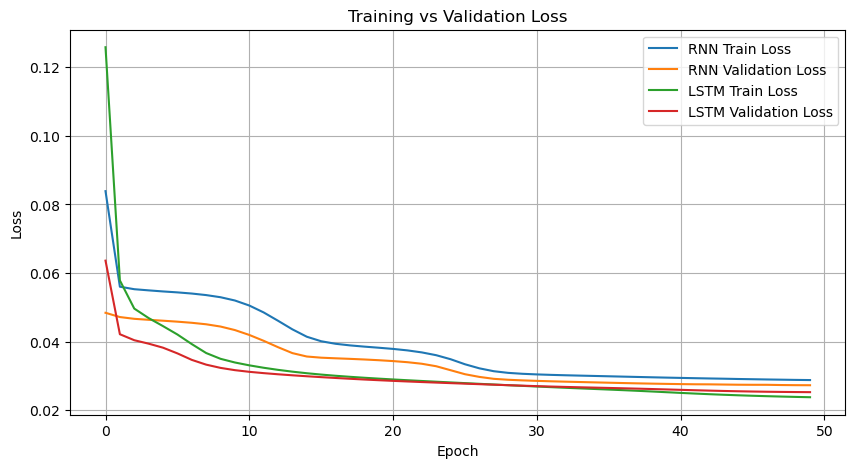

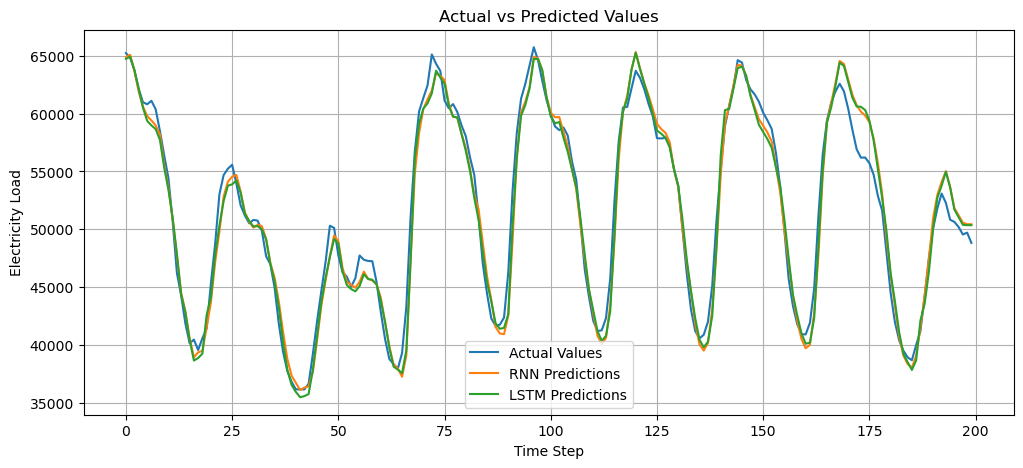

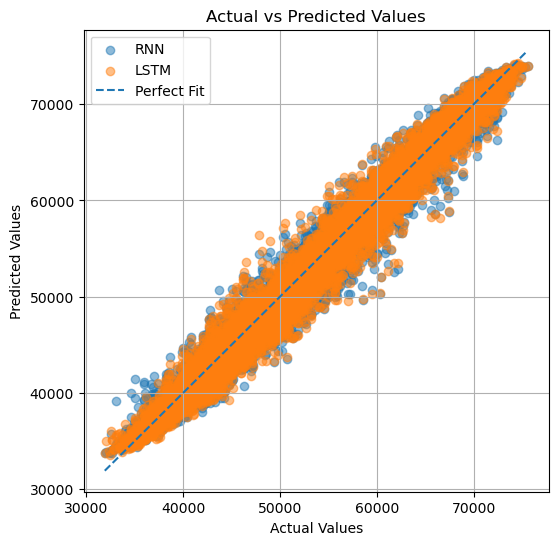

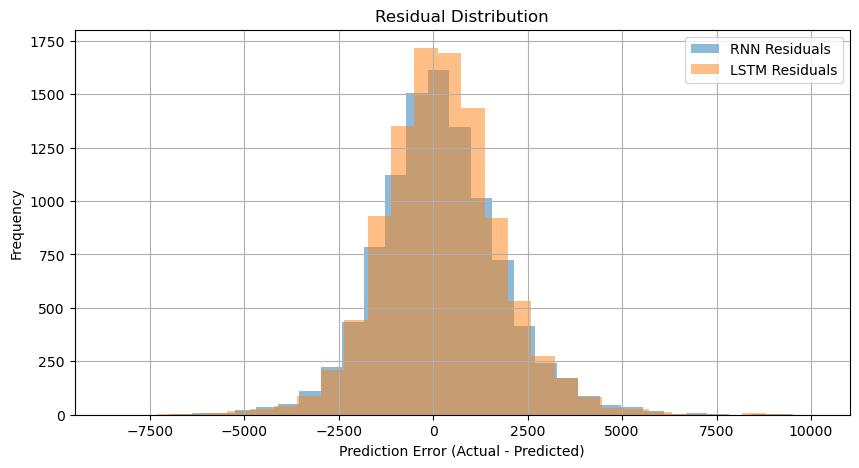

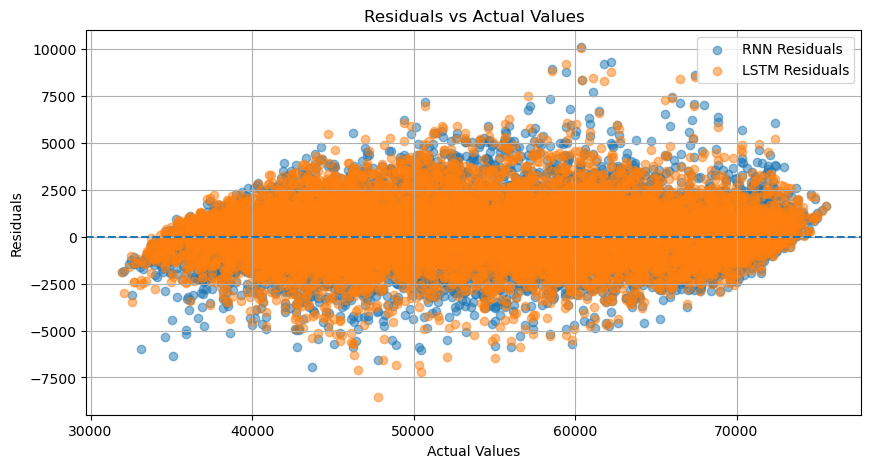

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt


#  DATA

df_model = df[["DE_load_actual_entsoe_transparency"]].dropna().copy()

df_model["lag_1"] = df_model["DE_load_actual_entsoe_transparency"].shift(1)
df_model["lag_24"] = df_model["DE_load_actual_entsoe_transparency"].shift(24)
df_model["lag_168"] = df_model["DE_load_actual_entsoe_transparency"].shift(168)

df_model = df_model.dropna()

X = df_model[["lag_1", "lag_24", "lag_168"]].values
y = df_model["DE_load_actual_entsoe_transparency"].values.reshape(-1, 1)

# Time-based split (no shuffle)
split_idx = int(len(X) * 0.8)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Standardization
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)

y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

# Reshape for RNN/LSTM: (samples, sequence_length, input_size)
X_train_torch = torch.tensor(X_train_scaled, dtype=torch.float32).reshape(-1, 3, 1)
X_test_torch = torch.tensor(X_test_scaled, dtype=torch.float32).reshape(-1, 3, 1)

y_train_torch = torch.tensor(y_train_scaled, dtype=torch.float32)
y_test_torch = torch.tensor(y_test_scaled, dtype=torch.float32)

train_dataset = TensorDataset(X_train_torch, y_train_torch)
test_dataset = TensorDataset(X_test_torch, y_test_torch)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

#  DEFINE MODELS

class RNNRegressor(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out


class LSTMRegressor(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out


#  TRAINING FUNCTION

def train_model(model, train_loader, test_loader, epochs=50, lr=1e-3):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        epoch_train_loss = 0.0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item()

        model.eval()
        epoch_val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                preds = model(X_batch)
                loss = criterion(preds, y_batch)
                epoch_val_loss += loss.item()

        train_losses.append(epoch_train_loss / len(train_loader))
        val_losses.append(epoch_val_loss / len(test_loader))

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(
                f"Epoch [{epoch+1}/{epochs}] "
                f"Train Loss: {train_losses[-1]:.6f} "
                f"Validation Loss: {val_losses[-1]:.6f}"
            )

    return train_losses, val_losses

#  EVALUATION FUNCTION

def evaluate_model(model, X_test_torch, y_test, y_scaler):
    model.eval()
    with torch.no_grad():
        preds_scaled = model(X_test_torch).cpu().numpy()

    preds = y_scaler.inverse_transform(preds_scaled)
    y_true = y_test

    mae = mean_absolute_error(y_true, preds)
    rmse = np.sqrt(mean_squared_error(y_true, preds))
    r2 = r2_score(y_true, preds)

    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²:   {r2:.4f}")

    return preds, {"MAE": mae, "RMSE": rmse, "R2": r2}


#  TRAIN RNN

torch.manual_seed(42)

rnn_model = RNNRegressor(input_size=1, hidden_size=32, num_layers=1)
print("=== Training RNN ===")
rnn_train_losses, rnn_val_losses = train_model(
    rnn_model,
    train_loader,
    test_loader,
    epochs=50,
    lr=1e-3
)

print("\n=== Evaluating RNN ===")
rnn_preds, rnn_metrics = evaluate_model(rnn_model, X_test_torch, y_test, y_scaler)

#  TRAIN LSTM

torch.manual_seed(42)

lstm_model = LSTMRegressor(input_size=1, hidden_size=32, num_layers=1)
print("\n=== Training LSTM ===")
lstm_train_losses, lstm_val_losses = train_model(
    lstm_model,
    train_loader,
    test_loader,
    epochs=50,
    lr=1e-3
)

print("\n=== Evaluating LSTM ===")
lstm_preds, lstm_metrics = evaluate_model(lstm_model, X_test_torch, y_test, y_scaler)

# COMPARE RESULTS

results = pd.DataFrame([
    {"Model": "RNN", **rnn_metrics},
    {"Model": "LSTM", **lstm_metrics}
])

print("\n=== Final Comparison ===")
print(results)


# PREDICTIONS

predictions_df = pd.DataFrame({
    "actual_values": y_test.flatten(),
    "rnn_predictions": rnn_preds.flatten(),
    "lstm_predictions": lstm_preds.flatten()
})

print("\nFirst predictions:")
print(predictions_df.head())

# VISUALIZATIONS


#  Training vs Validation Loss
plt.figure(figsize=(10, 5))

plt.plot(rnn_train_losses, label="RNN Train Loss")
plt.plot(rnn_val_losses, label="RNN Validation Loss")
plt.plot(lstm_train_losses, label="LSTM Train Loss")
plt.plot(lstm_val_losses, label="LSTM Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

#  Actual vs Predicted Values
plt.figure(figsize=(12, 5))

plt.plot(y_test.flatten()[:200], label="Actual Values")
plt.plot(rnn_preds.flatten()[:200], label="RNN Predictions")
plt.plot(lstm_preds.flatten()[:200], label="LSTM Predictions")

plt.title("Actual vs Predicted Values")
plt.xlabel("Time Step")
plt.ylabel("Electricity Load")
plt.legend()
plt.grid(True)
plt.show()

#  Scatter Plot: Actual vs Predicted
plt.figure(figsize=(6, 6))

plt.scatter(y_test.flatten(), rnn_preds.flatten(), alpha=0.5, label="RNN")
plt.scatter(y_test.flatten(), lstm_preds.flatten(), alpha=0.5, label="LSTM")

min_val = min(y_test.min(), rnn_preds.min(), lstm_preds.min())
max_val = max(y_test.max(), rnn_preds.max(), lstm_preds.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", label="Perfect Fit")

plt.title("Actual vs Predicted Values")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.legend()
plt.grid(True)
plt.show()

#  Residual Distribution
plt.figure(figsize=(10, 5))

rnn_residuals = y_test.flatten() - rnn_preds.flatten()
lstm_residuals = y_test.flatten() - lstm_preds.flatten()

plt.hist(rnn_residuals, bins=30, alpha=0.5, label="RNN Residuals")
plt.hist(lstm_residuals, bins=30, alpha=0.5, label="LSTM Residuals")

plt.title("Residual Distribution")
plt.xlabel("Prediction Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

#  Residuals vs Actual Values
plt.figure(figsize=(10, 5))

plt.scatter(y_test.flatten(), rnn_residuals, alpha=0.5, label="RNN Residuals")
plt.scatter(y_test.flatten(), lstm_residuals, alpha=0.5, label="LSTM Residuals")

plt.axhline(0, linestyle="--")

plt.title("Residuals vs Actual Values")
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.legend()
plt.grid(True)
plt.show()

*CONCLUSIONS*

Model Performance
Both RNN and LSTM are able to learn the general pattern of the electricity load.
Predictions follow the overall trend, especially in stable periods.
However, both models may struggle with:
sharp peaks
sudden drops
high volatility periods
 
2. RNN vs LSTM
LSTM usually performs better than RNN
Lower error (MAE / RMSE)
Better alignment in scatter plot
More stable predictions
WHYYY?
LSTM handles temporal dependencies better
It avoids the vanishing gradient problem that affects basic RNNs
 Conclusion:
LSTM is more suitable for time series forecasting than standard RNN

3. Loss Analysis
Training and validation loss decrease → model is learning
If validation loss increases → slight overfitting
If both plateau → model reached its capacity
Likely learning, but limited by input structure
 4. Scatter Plot Insights
Points close to diagonal → good predictions
Spread around diagonal → prediction error
 model:
Captures trend
But has noticeable dispersion → not highly precise
 
 5. Residual Analysis
Residuals centered around 0 → good
If skewed model bias
Slight bias + variance → model not fully capturing dynamics